# Tier 6 stability, trim and tail sizing verification

Tier 6 adds static stability and control for a conventional tail
(`controls/stability.py`):

* **Longitudinal:** downwash $\varepsilon = 2C_{L,w}/(\pi AR)$, neutral point
  from wing and tail lift slopes with Raymer's destabilizing fuselage term
  (eq. 16.25), static margin, and a pitching-moment equation for trim with an
  elevator; tail induced drag enters the Tier 5 drag-increment hook.
* **Directional:** $C_{n\beta}$ from the fin (end-plated effective AR) and the
  fuselage (Raymer eq. 16.47).
* **Asymmetric thrust:** yaw moment of a failed outboard rotor and the rudder
  deflection that holds it.
* Elevator and rudder use thin-airfoil flap effectiveness times a 0.8 viscous
  correction.

The controls code builds equations only. `examples/tail_sizing.py` sizes both
tails and the wing position inside the mass closure, minimizing take-off mass
under stability, trim and failed-rotor requirements expressed as Tier 3 margins.

```powershell
uv sync --group notebooks
uv run jupyter lab notebooks/tier6_stability_control
```

In [1]:
import ast
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import casadi as cas
import matplotlib.pyplot as plt

from aircraft_closure.aerodynamics.simple import SimpleAerodynamics
from aircraft_closure.controls.stability import (DirectionalStability, LongitudinalStability, flap_effectiveness,
                                                 failed_propulsor_yaw_moment_Nm)
from examples.aircraft_mass_closure import acceleration_gravity_m_s2, build_reference_aircraft, solve_mass_closure
from examples.tail_sizing import TailSizingRequirements, solve_tail_sizing

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


def close(a, b, rel=1e-9, abs_tol=1e-12):
    return abs(a - b) <= max(rel * abs(b), abs_tol)


closure = solve_mass_closure()
aircraft = build_reference_aircraft(closure.x_le_wing_m)
x_cg_m = closure.x_cg_m
aero, longitudinal, directional = SimpleAerodynamics(), LongitudinalStability(), DirectionalStability()
velocity_m_s, altitude_m = 60.0, 1000.0
ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8})

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


## 1. Control-surface effectiveness

Thin-airfoil theory gives $\tau = 1 - (\theta_f - \sin\theta_f)/\pi$ with
$\theta_f = \arccos(2c_f/c - 1)$: zero for no flap, one for an all-moving
surface. A 0.8 factor stands in for viscous losses (stated, not calibrated).

PASS  flap: tau(0) = 0
PASS  flap: tau(1) = 1 (all-moving)
PASS  flap: monotonic in chord fraction
elevator/rudder chord fraction 0.3: tau = 0.5286 (ideal 0.6607)


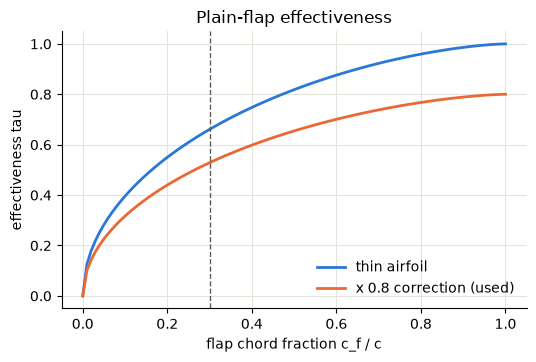

In [2]:
fractions = np.linspace(0, 1, 101)
tau_ideal = np.array([float(flap_effectiveness(f, correction=1.0)) for f in fractions])
check("flap: tau(0) = 0", abs(tau_ideal[0]) < 1e-12)
check("flap: tau(1) = 1 (all-moving)", close(tau_ideal[-1], 1.0))
check("flap: monotonic in chord fraction", np.all(np.diff(tau_ideal) > 0))
print(f"elevator/rudder chord fraction 0.3: tau = {float(flap_effectiveness(0.3)):.4f} (ideal {float(flap_effectiveness(0.3, 1.0)):.4f})")
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(fractions, tau_ideal, color=blue, lw=2, label="thin airfoil")
ax.plot(fractions, 0.8 * tau_ideal, color=orange, lw=2, label="x 0.8 correction (used)")
ax.axvline(0.3, color=ink_muted, lw=1, ls="--")
ax.set(xlabel="flap chord fraction c_f / c", ylabel="effectiveness tau", title="Plain-flap effectiveness")
ax.legend(frameon=False)
plt.show()

## 2. Neutral point and static margin

The static margin is $(x_{np} - x_{cg})/\bar c$, and by construction
$C_{m\alpha} = -SM\,C_{L\alpha,total}$; that identity is checked by finite
differences on the full pitching-moment equation. The tail moves the neutral
point aft; the fuselage moves it forward.

x_cg 3.521 m, x_np 3.662 m, static margin 12.15 % MAC
PASS  stability: Cm_alpha = -SM x CL_alpha_total (finite difference)
PASS  stability: reference aircraft is statically stable
PASS  stability: CG at the neutral point gives zero margin
PASS  stability: removing the fuselage term moves the neutral point aft
PASS  stability: static margin rises with horizontal-tail area


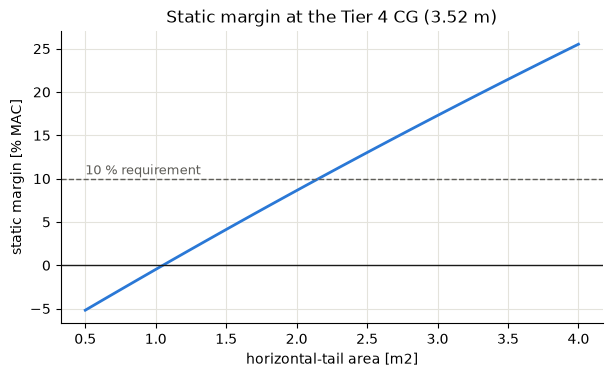

In [3]:
x_np_m = float(longitudinal.neutral_point_x_m(aircraft, aero, velocity_m_s, altitude_m))
static_margin = float(longitudinal.static_margin(aircraft, aero, x_cg_m, velocity_m_s, altitude_m))
print(f"x_cg {x_cg_m:.3f} m, x_np {x_np_m:.3f} m, static margin {100 * static_margin:.2f} % MAC")
h = 1e-4
cm_alpha = (float(longitudinal.evaluate(aircraft, aero, x_cg_m, velocity_m_s, altitude_m, 3 + h, 0).cm)
            - float(longitudinal.evaluate(aircraft, aero, x_cg_m, velocity_m_s, altitude_m, 3 - h, 0).cm)) / np.radians(2 * h)
slope_total = float(longitudinal.lift_curve_slope_total_per_rad(aircraft, aero, velocity_m_s, altitude_m))
check("stability: Cm_alpha = -SM x CL_alpha_total (finite difference)", close(cm_alpha, -static_margin * slope_total, rel=1e-6))
check("stability: reference aircraft is statically stable", static_margin > 0)
check("stability: CG at the neutral point gives zero margin", abs(float(longitudinal.static_margin(
    aircraft, aero, x_np_m, velocity_m_s, altitude_m))) < 1e-12)
check("stability: removing the fuselage term moves the neutral point aft", float(replace(
    longitudinal, fuselage_pitch_factor_per_deg=0).neutral_point_x_m(aircraft, aero, velocity_m_s, altitude_m)) > x_np_m)

areas_m2 = np.linspace(0.5, 4.0, 30)
margins = [float(longitudinal.static_margin(replace(aircraft, horizontal_tail=replace(aircraft.horizontal_tail, area_m2=a)),
                                            aero, x_cg_m, velocity_m_s, altitude_m)) for a in areas_m2]
check("stability: static margin rises with horizontal-tail area", np.all(np.diff(margins) > 0))
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(areas_m2, np.array(margins) * 100, color=blue, lw=2)
ax.axhline(10, color=ink_muted, lw=1, ls="--")
ax.text(areas_m2[0], 10.5, "10 % requirement", color=ink_muted, fontsize=9)
ax.axhline(0, color=ink, lw=1)
ax.set(xlabel="horizontal-tail area [m2]", ylabel="static margin [% MAC]",
       title=f"Static margin at the Tier 4 CG ({x_cg_m:.2f} m)")
plt.show()

## 3. Pitch trim

Trim solves $C_m = 0$ and trimmed lift = weight for $\alpha$ and elevator. The
nose-down wing moment ($C_{m,ac} = -0.09$) with the CG aft of the wing
aerodynamic centre needs a download on the tail (negative tail lift, trailing
edge up). Moving the CG aft reduces the required elevator, and at the neutral
point the elevator gradient with lift coefficient vanishes (up to the small
Mach dependence of the lift slopes).

trim at 60 m/s: alpha 3.510 deg, elevator -5.146 deg, CL_tail -0.1330, trim drag CD 0.00027
PASS  trim: tail carries a download
PASS  trim: trailing-edge-up elevator
PASS  trim: tail induced drag positive and small


PASS  trim: aft CG needs less trailing-edge-up elevator
PASS  trim: elevator nearly speed-independent at the neutral point (< 2 % of reference variation)


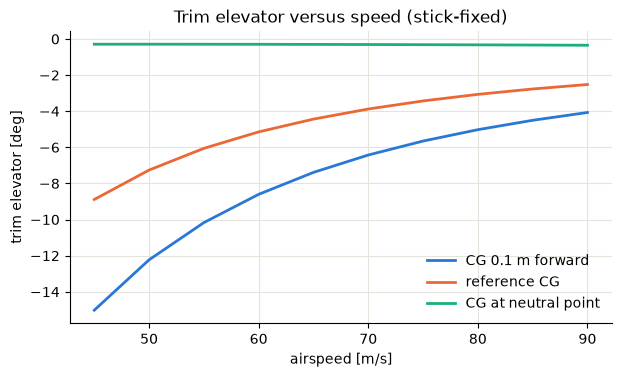

In [4]:
weight_N = closure.mass_takeoff_kg * acceleration_gravity_m_s2


def trim_at(x_cg, velocity):
    opti = asb.Opti()
    alpha = opti.variable(init_guess=3)
    elevator = opti.variable(init_guess=-3)
    result = longitudinal.evaluate(aircraft, aero, x_cg, velocity, altitude_m, alpha, elevator)
    opti.subject_to([result.cm == 0, result.lift_N == weight_N])
    sol = opti.solve(verbose=False)
    return float(sol.value(alpha)), float(sol.value(elevator)), float(sol.value(result.cl_tail)), float(sol.value(result.trim_drag.cd))


alpha_trim, elevator_trim, cl_tail_trim, trim_cd = trim_at(x_cg_m, velocity_m_s)
print(f"trim at 60 m/s: alpha {alpha_trim:.3f} deg, elevator {elevator_trim:.3f} deg, CL_tail {cl_tail_trim:.4f}, "
      f"trim drag CD {trim_cd:.5f}")
check("trim: tail carries a download", cl_tail_trim < 0)
check("trim: trailing-edge-up elevator", elevator_trim < 0)
check("trim: tail induced drag positive and small", 0 < trim_cd < 0.002)

speeds = np.linspace(45, 90, 10)
elevators_forward = [trim_at(x_cg_m - 0.1, v)[1] for v in speeds]
elevators_reference = [trim_at(x_cg_m, v)[1] for v in speeds]
elevators_neutral = [trim_at(x_np_m, v)[1] for v in speeds]
check("trim: aft CG needs less trailing-edge-up elevator", all(r > f for r, f in zip(elevators_reference, elevators_forward)))
# The neutral point was computed at 60 m/s; lift slopes carry a small Mach
# correction, so it moves slightly with speed and the elevator is nearly, not
# exactly, constant there.
check("trim: elevator nearly speed-independent at the neutral point (< 2 % of reference variation)",
      np.ptp(elevators_neutral) < 0.02 * np.ptp(elevators_reference))
fig, ax = plt.subplots(figsize=(7, 3.8))
for values, label, color in ((elevators_forward, "CG 0.1 m forward", blue), (elevators_reference, "reference CG", orange),
                             (elevators_neutral, "CG at neutral point", aqua)):
    ax.plot(speeds, values, color=color, lw=2, label=label)
ax.set(xlabel="airspeed [m/s]", ylabel="trim elevator [deg]", title="Trim elevator versus speed (stick-fixed)")
ax.legend(frameon=False)
plt.show()

## 4. Directional stability and failed-rotor yaw

$C_{n\beta}$ grows with fin area and arm; the fuselage alone is destabilizing.
With an outboard rotor failed at the wing tip, the remaining three rotors
supply level-flight drag, so the yaw moment is $(D/3)\,b/2$. The rudder needed
to hold it scales with the moment and inversely with dynamic pressure, so the
critical case is the slowest controlled speed (1.2 $V_{stall}$ here).

Cn_beta 0.0405 /rad (fuselage alone -0.0534 /rad)
PASS  directional: fuselage alone is destabilizing
PASS  directional: reference fin makes Cn_beta positive


PASS  failed rotor: required rudder is largest at the lowest speed


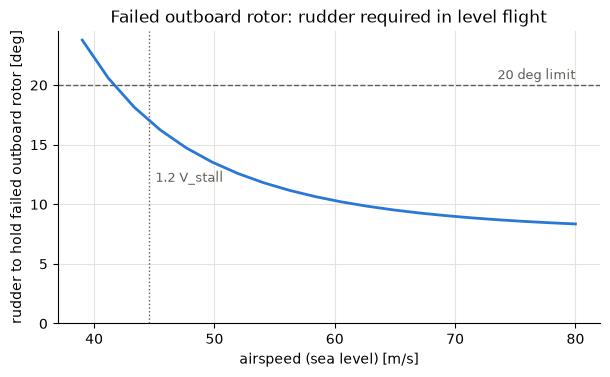

In [5]:
cn_beta = float(directional.cn_beta_per_rad(aircraft, aero, x_cg_m, velocity_m_s, altitude_m))
cn_beta_bare = float(directional.cn_beta_per_rad(replace(aircraft, vertical_tail=replace(aircraft.vertical_tail, area_m2=1e-6)),
                                                 aero, x_cg_m, velocity_m_s, altitude_m))
print(f"Cn_beta {cn_beta:.4f} /rad (fuselage alone {cn_beta_bare:.4f} /rad)")
check("directional: fuselage alone is destabilizing", cn_beta_bare < 0)
check("directional: reference fin makes Cn_beta positive", cn_beta > 0)

rho_sl = float(asb.Atmosphere(altitude=0).density())
velocity_stall = np.sqrt(2 * weight_N / (rho_sl * aircraft.wing.area_m2 * aero.cl_max))
speeds = np.linspace(1.05 * velocity_stall, 80, 20)
rudders = []
for v in speeds:
    opti = asb.Opti()
    alpha = opti.variable(init_guess=6)
    slow = aero.evaluate(aircraft, v, 0.0, alpha)
    opti.subject_to(slow.lift_N == weight_N)
    sol = opti.solve(verbose=False)
    moment = failed_propulsor_yaw_moment_Nm(float(sol.value(slow.drag_N)) / 3, aircraft.wing.span_m() / 2)
    rudders.append(float(directional.rudder_for_yaw_moment_deg(aircraft, aero, x_cg_m, v, 0.0, moment)))
check("failed rotor: required rudder is largest at the lowest speed", int(np.argmax(rudders)) == 0)
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(speeds, rudders, color=blue, lw=2)
ax.axhline(20, color=ink_muted, lw=1, ls="--")
ax.text(speeds[-1], 20.5, "20 deg limit", color=ink_muted, fontsize=9, ha="right")
ax.axvline(1.2 * velocity_stall, color=ink_muted, lw=1, ls=":")
ax.text(1.2 * velocity_stall + 0.5, max(rudders) * 0.5, "1.2 V_stall", color=ink_muted, fontsize=9)
ax.set(xlabel="airspeed (sea level) [m/s]", ylabel="rudder to hold failed outboard rotor [deg]", ylim=(0, None),
       title="Failed outboard rotor: rudder required in level flight")
plt.show()

## 5. Reference case: tail sizing inside the mass closure

Minimum take-off mass over wing position and both tail areas, with mass
closure, hover pitch trim (CG under the common rotor station), cruise trim,
static margin $\ge$ 10 %, $|\delta_e| \le$ 15 deg, $C_{n\beta} \ge$ 0.06 /rad and
failed-rotor rudder $\le$ 20 deg. The margin report names the binding
requirements: static margin sizes the horizontal tail and $C_{n\beta}$ the fin;
the failed-rotor case is satisfied with headroom.

cn_beta_per_rad           -0.0000
static_margin             -0.0000
rudder_failed_rotor_deg   +0.2968
elevator_cruise_up_deg    +0.6289
alpha_cruise_deg          +0.7318
elevator_cruise_down_deg  +1.3711

MTOM 1553.3 kg, S_h 2.156 m2, S_v 1.916 m2, rudder 14.06 deg at 44.6 m/s, elevator -5.57 deg
PASS  sizing: every requirement met
PASS  sizing: static margin and Cn_beta are the binding requirements
PASS  sizing: static margin exactly 10 %
PASS  sizing: Cn_beta exactly 0.06 /rad
PASS  sizing: horizontal tail shrinks from the Tier 4 guess
PASS  sizing: fin grows from the Tier 4 guess


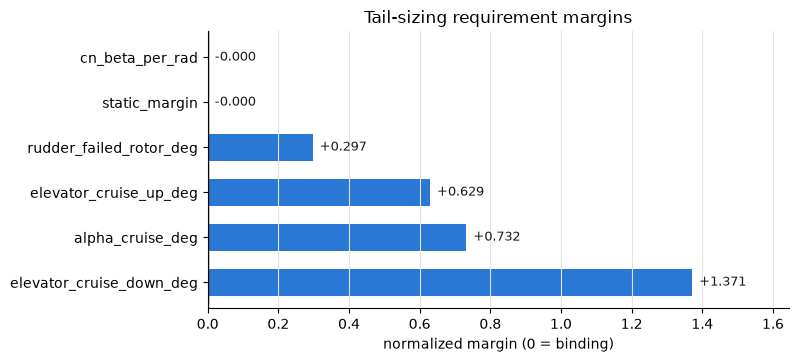

In [6]:
sizing = solve_tail_sizing()
for label, margin in sizing.margins:
    print(f"{label:<26}{margin:+.4f}")
print(f"\nMTOM {sizing.mass_takeoff_kg:.1f} kg, S_h {sizing.area_horizontal_tail_m2:.3f} m2, "
      f"S_v {sizing.area_vertical_tail_m2:.3f} m2, rudder {sizing.rudder_failed_rotor_deg:.2f} deg at "
      f"{sizing.velocity_minimum_control_m_s:.1f} m/s, elevator {sizing.elevator_cruise_deg:.2f} deg")
check("sizing: every requirement met", all(m > -1e-6 for _, m in sizing.margins))
binding = {label for label, m in sizing.margins if abs(m) < 1e-6}
check("sizing: static margin and Cn_beta are the binding requirements", binding == {"static_margin", "cn_beta_per_rad"})
check("sizing: static margin exactly 10 %", close(sizing.static_margin, 0.10, rel=1e-6))
check("sizing: Cn_beta exactly 0.06 /rad", close(sizing.cn_beta_per_rad, 0.06, rel=1e-6))
check("sizing: horizontal tail shrinks from the Tier 4 guess", sizing.area_horizontal_tail_m2 < 2.4)
check("sizing: fin grows from the Tier 4 guess", sizing.area_vertical_tail_m2 > 1.6)

labels = [l for l, _ in sizing.margins][::-1]
values = [m for _, m in sizing.margins][::-1]
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(labels, values, color=blue, height=0.6)
ax.axvline(0, color=ink, lw=1)
for y, v in enumerate(values):
    ax.text(v + 0.02, y, f"{v:+.3f}", va="center", fontsize=9, color=ink)
ax.set(xlabel="normalized margin (0 = binding)", xlim=(0, max(values) * 1.2), title="Tail-sizing requirement margins")
ax.grid(axis="y", visible=False)
plt.show()

In [7]:
# Requirement sweep: stricter static margin grows the horizontal tail and the mass.
targets = [0.05, 0.10, 0.15, 0.20]
sweep = [solve_tail_sizing(TailSizingRequirements(static_margin_min=t)) for t in targets]
areas = [s.area_horizontal_tail_m2 for s in sweep]
for t, s in zip(targets, sweep):
    print(f"SM >= {t:.2f}: S_h {s.area_horizontal_tail_m2:.3f} m2, MTOM {s.mass_takeoff_kg:.2f} kg")
check("sweep: horizontal-tail area rises with the static-margin requirement", np.all(np.diff(areas) > 0))
check("sweep: MTOM rises with the static-margin requirement", np.all(np.diff([s.mass_takeoff_kg for s in sweep]) > 0))

SM >= 0.05: S_h 1.592 m2, MTOM 1550.44 kg
SM >= 0.10: S_h 2.156 m2, MTOM 1553.33 kg
SM >= 0.15: S_h 2.739 m2, MTOM 1556.25 kg
SM >= 0.20: S_h 3.342 m2, MTOM 1559.21 kg
PASS  sweep: horizontal-tail area rises with the static-margin requirement
PASS  sweep: MTOM rises with the static-margin requirement


## 6. Symbolic use and boundaries

Tail areas and trim variables are Opti variables throughout. The controls
package imports only the aerodynamics discipline (for the drag-increment type)
and AeroSandbox, never the vehicle or powertrain layers, and references no
Opti API.

In [8]:
opti = asb.Opti()
area = opti.variable(init_guess=2.0, lower_bound=0.3)
symbolic_margin = longitudinal.static_margin(replace(aircraft, horizontal_tail=replace(aircraft.horizontal_tail, area_m2=area)),
                                             aero, x_cg_m, velocity_m_s, altitude_m)
check("symbolic: static margin with a variable tail area is CasADi MX", isinstance(symbolic_margin, cas.MX))
opti.subject_to(symbolic_margin == 0.10)
sol = opti.solve(verbose=False)
check("symbolic: solving SM = 10 % for the tail area gives a positive area", float(sol.value(area)) > 0)

tree = ast.parse((repo_root / "src/aircraft_closure/controls/stability.py").read_text(encoding="utf-8"))
imports = {n.module for n in ast.walk(tree) if isinstance(n, ast.ImportFrom)}
used = {n.id for n in ast.walk(tree) if isinstance(n, ast.Name)} | {n.attr for n in ast.walk(tree) if isinstance(n, ast.Attribute)}
check("boundaries: controls imports no vehicle or powertrain module",
      not any(("vehicle" in (m or "")) or ("powertrain" in (m or "")) for m in imports))
check("boundaries: controls references no Opti API",
      not used & {"Opti", "variable", "subject_to", "solve", "minimize", "parameter"})

PASS  symbolic: static margin with a variable tail area is CasADi MX
PASS  symbolic: solving SM = 10 % for the tail area gives a positive area
PASS  boundaries: controls imports no vehicle or powertrain module
PASS  boundaries: controls references no Opti API


## 7. Summary and unit test suite

In [9]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

28 / 28 notebook checks passed


In [10]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

.

.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 310 tests in 72.648s

OK
